# Unidad 4 — Notebook 2: Random Forest

**Materia:** Métodos de Análisis de Datos 1 (MAD1)  
**Departamento de Matemática — Universidad Nacional del Sur (UNS)**  
**Nombre:**  
**Fecha:**

---

## Glosario de siglas

| Sigla | Significado |
|-------|-------------|
| RF | Random Forest (Bosque Aleatorio) |
| CART | Classification and Regression Trees (Árboles de Clasificación y Regresión) |
| OOB | Out-of-Bag (Fuera de la Bolsa) — observaciones no usadas en cada árbol de bootstrap |
| MDI | Mean Decrease in Impurity (Disminución Media de Impureza) |
| MDA | Mean Decrease in Accuracy (Disminución Media de Accuracy) |
| CV | Cross-Validation (Validación Cruzada) |

---

## Objetivos

- Comprender el mecanismo de bootstrap y el error OOB calculando a mano un ensemble pequeño.
- Implementar Random Forest con scikit-learn y analizar la importancia de variables.
- Comparar RF con un árbol individual en términos de varianza.

---

## Parte 1 — Cálculo a mano: bootstrap y error OOB

Tenemos un dataset de **5 observaciones** y entrenamos un ensemble de **3 árboles**. Cada árbol se entrena con una muestra bootstrap (con reposición) de tamaño $n = 5$.

Las muestras bootstrap asignadas son:

| Árbol | Observaciones en bootstrap | OOB |
|-------|---------------------------|-----|
| $T_1$ | {1, 1, 2, 4, 5}           | {3} |
| $T_2$ | {1, 2, 3, 3, 5}           | {4} |
| $T_3$ | {2, 3, 4, 4, 5}           | {1} |

Las predicciones de cada árbol sobre **todas** las observaciones son:

| Obs | Clase real | $T_1$ predice | $T_2$ predice | $T_3$ predice |
|-----|-----------|--------------|--------------|--------------|
| 1   | Sí        | Sí           | Sí           | No           |
| 2   | No        | No           | Sí           | No           |
| 3   | Sí        | No           | Sí           | Sí           |
| 4   | No        | No           | No           | Sí           |
| 5   | Sí        | Sí           | Sí           | Sí           |

**Ejercicio 1.1** — Para cada observación, identificá cuáles árboles la tienen como OOB (es decir, en qué árboles NO fue usada para entrenar).

*Ayuda: la tabla de arriba ya te lo dice para $T_1$, $T_2$, $T_3$. Completá la columna 'Árboles OOB' para cada obs.*

La observación 1 aparece como OOB para $T_3$, la observación 3 es OOB para $T_1$ y la observación 4 es OOB para $T_2$. Tanto la observación 2 como la 5 no son OOB para ninguno de los 3 árboles.

**Ejercicio 1.2** — Para cada observación, calculá la predicción OOB por mayoría de votos (usando solo los árboles para los que esa observación es OOB).

Obs. 1 es OOB para $T_3$. Luego, mirando la segunda tabla, $T_3(1)={\text{No}}$

Obs. 3 es OOB para $T_1$. Luego, mirando la segunda tabla, $T_1(3)={\text{No}}$

Obs. 4 es OOB para $T_2$. Luego, mirando la segunda tabla, $T_2(4)={\text{No}}$

**Ejercicio 1.3** — Calculá el error OOB del ensemble. El error OOB se define como la proporción de observaciones mal clasificadas por su predicción OOB.

$$\text{Error OOB} = \frac{\text{cantidad de obs. mal clasificadas por su predicción OOB}}{n}$$

Comparamos la clase real con lo que predice cada árbol para las observaciones OOB. Si coinciden están bien clasificadas.

Las observaciones 1 y 3 está mal clasificadas, y la 4 está bien.

Luego, $$\text{Error OOB}=\frac{2}{5}=0.4$$

**Ejercicio 1.4** — ¿Por qué el error OOB es una estimación válida del error de generalización sin necesitar un conjunto de test separado? ¿Qué relación tiene con la validación cruzada (CV)?

El error OOB es válido para estimar el error de generalización porque cada árbol de Random Forest se entrena con una muestra bootstrap, lo que siempre deja observaciones sin usar al entrenarse. Esas observaciones evaluan el desempeño del árbol y al combinar las OOB de todos los árboles, se obtiene una estimación del rendimiento del modelo sobre datos no vistos.

Al igual que la validación cruzada, busca estimar la capacidad de generalización utilizando datos que no entrenaron. Sin embargo, CV divide los datos en varios pliegues y entrena varias veces al modelo. 

---

## Parte 2 — Random Forest con scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=500, n_features=10, n_informative=5,
    n_redundant=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)



**Ejercicio 2.1** — Entrenás un árbol de decisión simple y un RF (Random Forest) con 100 árboles. Completá el código.

In [2]:
# Árbol individual
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train, y_train)  # TU CÓDIGO ACÁ

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,   # TU CÓDIGO ACÁ: 100 árboles
    oob_score=True,     # activa el cálculo del error OOB
    random_state=42
)
rf.fit(X_train, y_train)  # TU CÓDIGO ACÁ

print(f"Accuracy árbol individual (test): {accuracy_score(y_test, arbol.predict(X_test)):.3f}")
print(f"Accuracy RF (test):               {accuracy_score(y_test, rf.predict(X_test)):.3f}")
print(f"Error OOB del RF:                 {1 - rf.oob_score_:.3f}")

Accuracy árbol individual (test): 0.880
Accuracy RF (test):               0.880
Error OOB del RF:                 0.094


**Ejercicio 2.2** — ¿El error OOB que reporta scikit-learn se aproxima al error en test? ¿Qué conclusión sacás?

El error del test es $1-\text{Accuracy RF}=1-0.880=0.120$. Teniendo en cuenta que el Error OOB es 0.094, podemos decir que está bastante cerca del error del test (la diferencia es de 0.026). Concluimos entonces que el error OOB proporciona una buena estimación del error de generalización del Random Forest.

**Ejercicio 2.3** — Graficá la importancia MDI (Mean Decrease in Impurity) de cada variable. Completá el código.

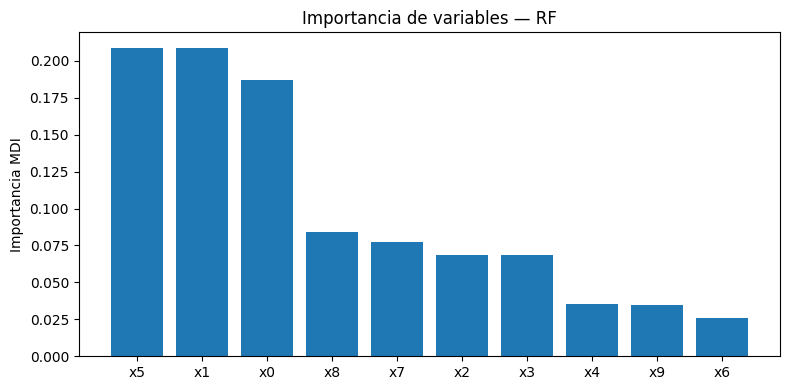

In [3]:
importancias = rf.feature_importances_
nombres = [f'x{i}' for i in range(X.shape[1])]
orden = np.argsort(importancias)[::-1]  # TU CÓDIGO ACÁ: ordenar de mayor a menor

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(nombres)), importancias[orden])
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels([nombres[i] for i in orden])
ax.set_ylabel('Importancia MDI')
ax.set_title('Importancia de variables — RF')
plt.tight_layout()
plt.show()

**Ejercicio 2.4** — ¿Las 5 variables más importantes coinciden con las `n_informative=5` del dataset generado? ¿Qué limitación tiene la importancia MDI para detectar variables relevantes?

El dataset se genero con 5 variables informativas. En el gráfico observado en el ejercicio anterior, vemos que para el Random Forest, las 5 variables más importantes son $x_5$, $x_1$, $x_0$, $x_8$ y $x_7$. Pero no podemos asegurar con el gráfico si coinciden o no con las 5 variables informativas del dataset ya que make_classifcation mezcla las variables por defecto. 

La limitación de la importancia MDI es que puede favorecer variables con mayor capacidad de generar splits. No siempre identifica correctamente a las variables informativas. 

**Ejercicio 2.5** — Analizá el efecto del número de árboles (`n_estimators`) sobre el error OOB. Entrenás RF con 5, 10, 25, 50, 100, 200 árboles y graficás el error OOB en función de `n_estimators`.

C:\Users\ferra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


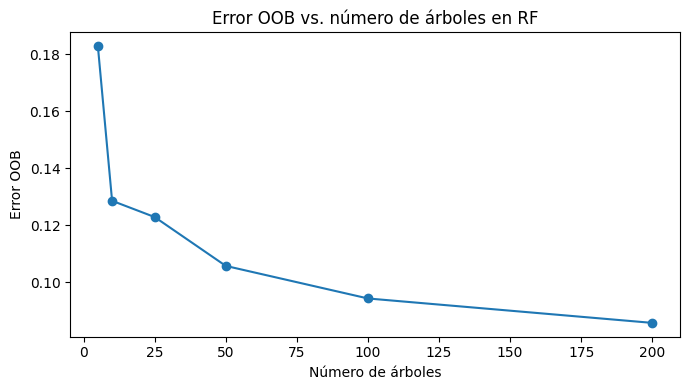

In [4]:
n_arboles = [5, 10, 25, 50, 100, 200]
errores_oob = []

for n in n_arboles:
    rf_n = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)  # TU CÓDIGO ACÁ
    rf_n.fit(X_train, y_train)                                                                  # TU CÓDIGO ACÁ
    errores_oob.append(1 - rf_n.oob_score_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_arboles, errores_oob, marker='o')
ax.set_xlabel('Número de árboles')
ax.set_ylabel('Error OOB')
ax.set_title('Error OOB vs. número de árboles en RF')
plt.tight_layout()
plt.show()

**Ejercicio 2.6** — ¿A partir de cuántos árboles el error OOB se estabiliza? ¿Qué implicancia tiene esto para elegir `n_estimators` en la práctica?

Observando el gráfico anterior, podemos notar que a partir de los 100 árboles el error comienza a estabilizarse. A partir de ese punto, agrefar más árboles produce tan sólo una pequeña mejora en el error. 

En la práctica, esto nos nos dice que nos conviene elegir un valor de n_estimators cercano a donde se estabiliza el error OOB pues agregar más árboles es más costoso computacionalmente y la ganancia no es significativa.

---

## Preguntas de reflexión final

1. Random Forest reduce la varianza respecto a un árbol individual. ¿Por qué? ¿Qué papel juega la aleatoriedad en la selección de features en cada split?
2. ¿Por qué RF no reduce el sesgo respecto a un árbol individual?
3. Si tuvieras un dataset con 10.000 observaciones y 500 variables, ¿preferirías usar importancia MDI o MDA (Mean Decrease in Accuracy)? Justificá.

1. Los árboles son mas sensibles a pequeñas variaciones en la muestra pueden producir cambios importantes en la estructura del árbol y en sus predicciones. Random Forest reduce la varianza construyendo muchos árboles y agregando sus predicciones por promedio o votación. 
La aleatoridad en la selección en cada split descorrelaciona los árboles ya que al considerar solo un subconjunto aleatorio de variables en cada nodo, se evita que todos los árboles elijan las mismas variables dominantes que generan árboles más diversos. 

2. Random Forest reduce la varianza y no el sesgo porque se construye combinando árboles de decisión. El promedio de estimadores inestables disminuye la dispersión de las predicciones, sin modificar demasiado el valor esperado, de modo de que el sesgo se mantiene aproximadamente igual al del árbol individual.

3. En el caso de tener 10.000 observaciones y 500 variables, lo óptimo sería usar MDA. Aun que MDA sea más costosa computacionalmente y pueda subestimar variables fuertemente correlacionadas, evalúa la pérdida de desempeño al permutar una variable, lo que refleja mejor su aporte predictivo al modelo. 